## Karar Ağaçları (CART) - Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from warnings import filterwarnings
filterwarnings('ignore')

In [30]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [3]:
X_train = pd.DataFrame(X_train["Hits"])
X_test = pd.DataFrame(X_test["Hits"])

In [4]:
cart_model = DecisionTreeRegressor(max_leaf_nodes = 10)

In [5]:
cart_model.fit(X_train, y_train)

DecisionTreeRegressor(max_leaf_nodes=10)

In [6]:
#Modelin gorsellestirilmesi

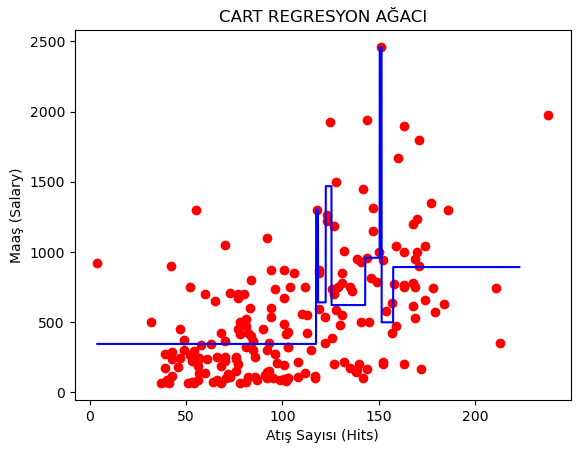

In [7]:
X_grid = np.arange(min(np.array(X_train)), max(np.array(X_test)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_grid, cart_model.predict(X_grid), color = 'blue')
plt.title('CART REGRESYON AĞACI')
plt.xlabel('Atış Sayısı (Hits)')
plt.ylabel('Maaş (Salary)') ;

In [8]:
#karar kural seti

In [9]:
from skompiler import skompile

In [10]:
print(skompile(cart_model.predict).to('python/code'))

(345.2011551724138 if x[0] <= 117.5 else ((((1300.0 if x[0] <= 118.5 else 
    641.0) if x[0] <= 122.5 else 1468.5236666666667) if x[0] <= 125.5 else 
    621.9679230769232) if x[0] <= 143.0 else (958.6111111111111 if x[0] <= 
    150.5 else 2460.0) if x[0] <= 151.5 else 499.1666666666667 if x[0] <= 
    157.5 else 892.5402413793104) if x[0] <= 225.5 else 1975.0)



## Tahmin

In [11]:
x = [91]

In [12]:
345.2011551724138 if x[0] <= 117.5 else ((((1300.0 if x[0] <= 118.5 else 
    641.0) if x[0] <= 122.5 else 1468.5236666666667) if x[0] <= 125.5 else 
    621.9679230769232) if x[0] <= 143.0 else (958.6111111111111 if x[0] <= 
    150.5 else 2460.0) if x[0] <= 151.5 else 499.1666666666667 if x[0] <= 
    157.5 else 892.5402413793104) if x[0] <= 225.5 else 1975.0

345.2011551724138

In [13]:
cart_model.predict(X_test)[0:5]

array([621.96792308, 958.61111111, 621.96792308, 345.20115517,
       345.20115517])

In [14]:
cart_model.predict([[91]])

array([345.20115517])

*Kural setinin doğru çalıştığını el yordamıyla doğrulamış olduk.*

In [15]:
#rmse

In [16]:
y_pred = cart_model.predict(X_test)

In [17]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(486.34593105235456)

## Model Tuning

*Optimum parametre değerini bulmak için parametre değeri girmeden model oluşturma işlemini tekrar yapacağız.*

In [18]:
cart_model = DecisionTreeRegressor()
cart_model.fit(X_train, y_train)
y_pred = cart_model.predict(X_test)

In [19]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(468.49579052913884)

In [31]:
cart_params = {'min_samples_split' : range(2,100),
               'max_leaf_nodes' : range(2,10)}

In [32]:
cart_cv_model = GridSearchCV(cart_model, cart_params, cv = 10)

In [33]:
cart_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'max_leaf_nodes': range(2, 10),
                         'min_samples_split': range(2, 100)})

In [34]:
cart_cv_model.best_params_

{'max_leaf_nodes': 9, 'min_samples_split': 37}

In [24]:
#tune edilmis model

In [25]:
cart_tuned = DecisionTreeRegressor(max_leaf_nodes = 9, min_samples_split = 76)

In [26]:
cart_tuned.fit(X_train, y_train)

DecisionTreeRegressor(max_leaf_nodes=9, min_samples_split=76)

In [27]:
#final test hatasi

In [28]:
y_pred = cart_tuned.predict(X_test)

In [29]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(423.406689243066)

*Bu tek bir bağımsız değişken ile kurduğumuz modelin test hatası. Veri setinin bütününü kullanarak bir test hatası hesaplama işlemi de yapalım.*

In [35]:
cart_tuned = DecisionTreeRegressor(max_leaf_nodes = 9, min_samples_split = 37)

In [36]:
cart_tuned.fit(X_train, y_train)

DecisionTreeRegressor(max_leaf_nodes=9, min_samples_split=37)

In [37]:
#butun veri seti ile egitilen modelin test hatasi

In [38]:
y_pred = cart_tuned.predict(X_test)

In [39]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(376.39788207109865)